In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)


# Dataset paths

import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Root dataset folder
dataset_path = "/user/HS400/mk03022/Downloads/melonoma_dataset"

# CSV and image paths
train_csv_path = os.path.join(dataset_path, "train.csv")
train_images_path = os.path.join(dataset_path, "train")

In [40]:
df = pd.read_csv(train_csv_path)
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,0,1872,1053
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,11,6000,4000


In [41]:
row = df.iloc[0]

image_name = row["image_name"]
label = row["target"]

print("Image:", image_name)
print("Label:", label)

Image: ISIC_2637011
Label: 0


In [42]:
image_path = os.path.join(train_images_path, image_name + ".jpg")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

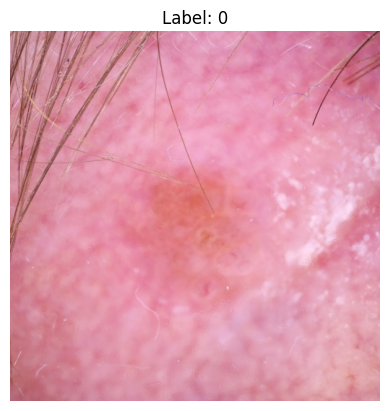

In [24]:
image = Image.open(image_path)

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

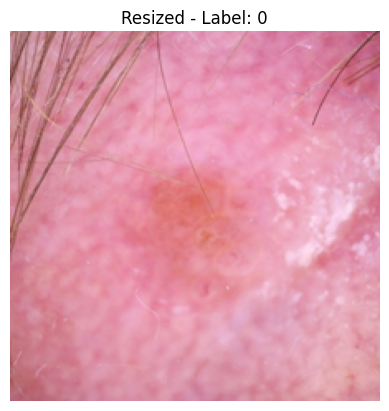

In [25]:
image = image.resize((224, 224))

plt.imshow(image)
plt.title(f"Resized - Label: {label}")
plt.axis("off")

In [26]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA RTX A4000


In [27]:
import torchvision.transforms as transforms

transform = transforms.ToTensor()

image_tensor = transform(image)

print(image_tensor.shape)

torch.Size([3, 224, 224])


In [28]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_tensor = transform(image)

print(image_tensor.shape)

torch.Size([3, 224, 224])


In [29]:
# Import PyTorch core libraries
import torch
from torch.utils.data import Dataset

In [30]:
# Custom Dataset class for loading melanoma images and labels
class MelanomaDataset(Dataset):
    
    def __init__(self, dataframe, image_folder, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): CSV file with image names and labels
            image_folder (str): Path to folder containing images
            transform (callable, optional): Transformations to apply to images
        """
        self.df = dataframe
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        """
        Returns total number of samples in dataset
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Loads one image + its label using index
        """
        # Get row
        row = self.df.iloc[idx]
        
        # Get image name and label
        image_name = row["image_name"]
        label = row["target"]

        # Build full image path
        image_path = os.path.join(self.image_folder, image_name + ".jpg")

        # Load image
        image = Image.open(image_path).convert("RGB")  # Ensure 3 channels

        # Apply transformations (resize, tensor, normalization)
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [31]:
# Create dataset instance using our custom class
dataset = MelanomaDataset(
    dataframe=df,
    image_folder=train_images_path,
    transform=transform
)

# Check dataset size
print("Total samples:", len(dataset))

Total samples: 33126


In [32]:
# Get one sample from dataset
image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: tensor(0.)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.055322..2.465708].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

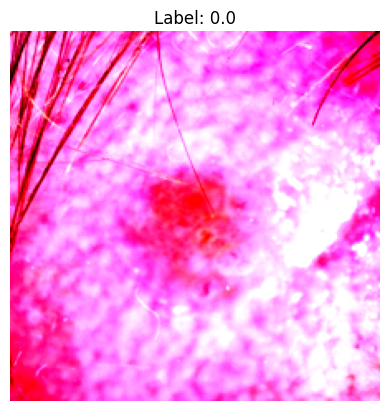

In [33]:
# Convert tensor back to image for visualization
# (Undo normalization approximately for display)

import numpy as np

img = image.permute(1, 2, 0).numpy()  # Convert CHW → HWC

plt.imshow(img)
plt.title(f"Label: {label.item()}")
plt.axis("off")

In [34]:
# Import DataLoader to handle batching and shuffling
from torch.utils.data import DataLoader

In [35]:
# Create DataLoader for batching data

train_loader = DataLoader(
    dataset,          # our dataset
    batch_size=16,    # number of samples per batch (safe starting point)
    shuffle=True      # shuffle data each epoch for better learning
)

In [36]:
# Get one batch from DataLoader

images, labels = next(iter(train_loader))

# Print shapes
print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)

Batch image shape: torch.Size([16, 3, 224, 224])
Batch labels shape: torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7556022..1.7009162].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

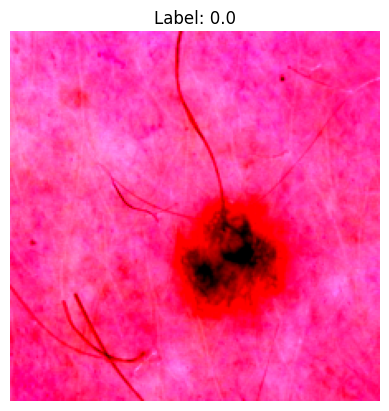

In [37]:
# Show first image in the batch (for sanity check)

img = images[0].permute(1, 2, 0).numpy()

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")

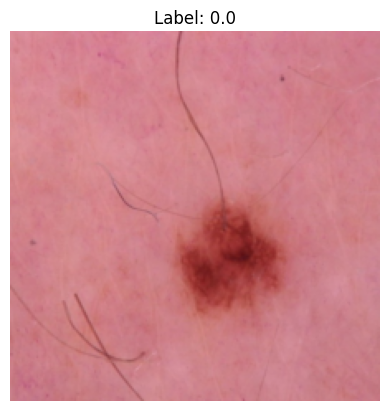

In [38]:
# Function to unnormalize image for display
def show_image(tensor, label):
    img = tensor.clone().detach()
    img = img.permute(1, 2, 0).numpy()
    
    # Undo normalization
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    
    img = img * std + mean
    img = img.clip(0, 1)

    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

show_image(images[0], labels[0].item())

In [39]:
# Import function to split dataset into train and validation
from sklearn.model_selection import train_test_split

In [40]:
# Split dataframe into train and validation sets (80/20)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,       # 20% for validation
    stratify=df["target"],  # VERY IMPORTANT (keeps class balance)
    random_state=42      # ensures reproducibility
)

# Print sizes
print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 26500
Validation size: 6626


In [41]:
# Create dataset objects for train and validation

train_dataset = MelanomaDataset(
    dataframe=train_df,
    image_folder=train_images_path,
    transform=transform
)

val_dataset = MelanomaDataset(
    dataframe=val_df,
    image_folder=train_images_path,
    transform=transform
)

In [42]:
# Create DataLoaders for train and validation

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True   # shuffle only training data
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False  # DO NOT shuffle validation data
)

In [43]:
# Check one batch from train loader
train_images, train_labels = next(iter(train_loader))

print("Train batch:", train_images.shape)

# Check one batch from validation loader
val_images, val_labels = next(iter(val_loader))

print("Validation batch:", val_images.shape)

Train batch: torch.Size([16, 3, 224, 224])
Validation batch: torch.Size([16, 3, 224, 224])


In [44]:
####ResNet Now

In [45]:
# Import torchvision models and neural network tools
import torchvision.models as models
import torch.nn as nn

In [46]:
# Load ResNet50 with pretrained ImageNet weights
# model = models.resnet50(pretrained=True)

from torchvision.models import resnet50, ResNet50_Weights

# Load model with latest recommended weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)

In [47]:
# Replace final fully connected layer

num_features = model.fc.in_features  # number of input features to last layer

model.fc = nn.Linear(num_features, 1)  # output = 1 (binary)

In [48]:
# Set device (CPU in your case)
# device = torch.device("cpu")

# Automatically use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Move model to device
model = model.to(device)

Using device: cuda


In [49]:
# Take one batch from train_loader
images, labels = next(iter(train_loader))

# Move data to device
images = images.to(device)

# Forward pass (no training yet)
outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([16, 1])


In [50]:
# Store baseline probabilities for ROC analysis

baseline_probs = []
baseline_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        
        images = images.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        
        baseline_probs.extend(probs.cpu().numpy())
        baseline_labels.extend(labels.numpy())

In [51]:
# Compute baseline ROC and AUC

from sklearn.metrics import roc_curve, auc

baseline_labels_flat = [int(l) for l in baseline_labels]
baseline_probs_flat = [p[0] for p in baseline_probs]

baseline_fpr, baseline_tpr, _ = roc_curve(
    baseline_labels_flat,
    baseline_probs_flat
)

baseline_auc = auc(baseline_fpr, baseline_tpr)

print("Baseline AUC:", baseline_auc)

Baseline AUC: 0.6328213532085094


In [52]:
# Weighted BCE

In [53]:
# Calculate class imbalance

num_zeros = (train_df["target"] == 0).sum()
num_ones = (train_df["target"] == 1).sum()

print("Class 0:", num_zeros)
print("Class 1:", num_ones)

Class 0: 26033
Class 1: 467


In [54]:
# Calculate positive class weight

# pos_weight = torch.tensor([num_zeros / num_ones], dtype=torch.float32).to(device)
pos_weight = torch.tensor([num_zeros / num_ones]).to(device)

print("Positive class weight:", pos_weight)

Positive class weight: tensor([55.7452], device='cuda:0', dtype=torch.float64)


In [55]:
# Defigning Weighted Loss Function


# # Binary Cross Entropy with logits (handles sigmoid internally) (Old)
# criterion = nn.BCEWithLogitsLoss()

# Weighted loss function to handle class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [56]:
# Defigning Optimizer

# Optimizer controls how model learns
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001   # safe starting learning rate
)

In [57]:
labels = labels.unsqueeze(1)  # convert [16] → [16, 1]

In [58]:
# Testing loss calculations

# Take one batch
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.unsqueeze(1).to(device)

# Forward pass
outputs = model(images)

# Compute loss
loss = criterion(outputs, labels)

print("Loss:", loss.item())

Loss: 0.6570512056350708


In [59]:
# Training Loop

In [60]:
# Number of times the model sees the entire dataset
num_epochs = 2   # small for now (CPU friendly)

In [66]:
# Training Loop

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

num_epochs = 2

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ---------------- TRAINING ----------------
    model.train()

    total_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        # Move data to device
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

        # Predictions
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Average train loss
    train_loss = total_loss / len(train_loader)

    # Train accuracy
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.4f}")

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss_total = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss_total += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    # Average validation loss
    val_loss = val_loss_total / len(val_loader)

    # Validation accuracy
    val_acc = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/2
Training Loss: 0.8908
Training Accuracy: 0.7218
Validation Loss: 1.6054
Validation Accuracy: 0.7631

Epoch 2/2
Training Loss: 0.8185
Training Accuracy: 0.7255
Validation Loss: 0.9457
Validation Accuracy: 0.7572


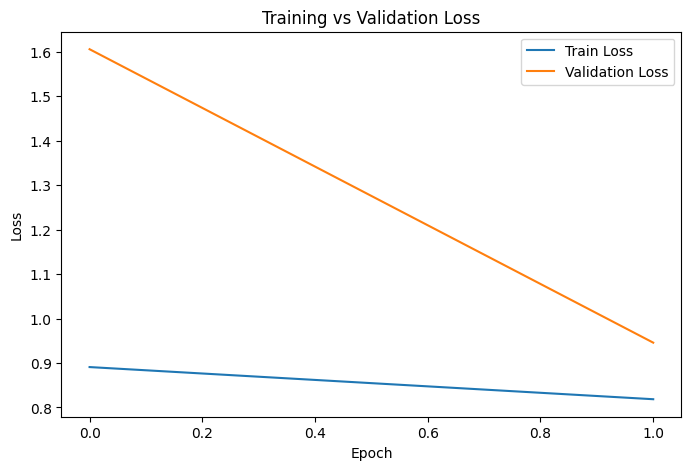

In [70]:
import matplotlib.pyplot as plt

# Loss Curve
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

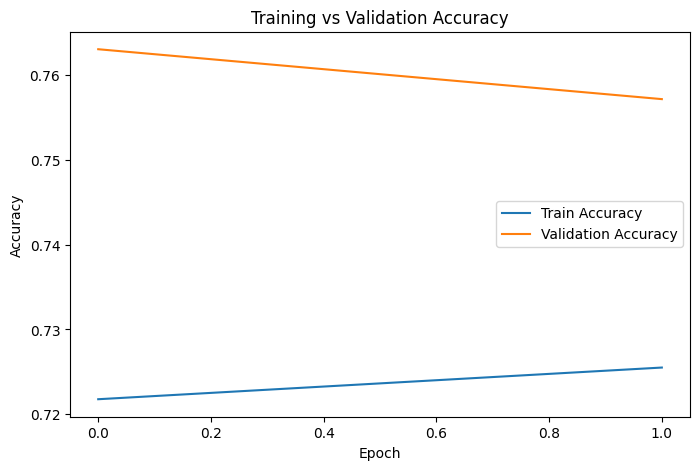

In [73]:
# Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [74]:
# Check how many batches are in your DataLoader
print("Number of batches:", len(train_loader))

Number of batches: 1657


In [75]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    model.train()
    total_loss = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        
        # DEBUG: print first few batches
        if batch_idx < 3:
            print(f"Processing batch {batch_idx}")
        
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Training Loss: {avg_loss:.4f}")


Epoch 1/2
Processing batch 0
Processing batch 1
Processing batch 2
Training Loss: 0.7599

Epoch 2/2
Processing batch 0
Processing batch 1
Processing batch 2
Training Loss: 0.7105


In [76]:
# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# Disable gradient computation (faster + safer)
with torch.no_grad():
    
    for images, labels in val_loader:
        
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        
        outputs = model(images)
        
        # Convert logits → probabilities
        probs = torch.sigmoid(outputs)
        
        # Convert probabilities → binary predictions
        preds = (probs > 0.5).float()
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

# Calculate accuracy
accuracy = correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.78765469363115


In [77]:
# Print predictions safely
for i in range(len(preds)):
    print(f"Pred: {preds[i].item()} | Actual: {labels[i].item()}")

Pred: 0.0 | Actual: 0.0
Pred: 0.0 | Actual: 0.0


In [78]:
# Store all predictions and labels
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.7).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert to flat arrays
all_preds = [int(p[0]) for p in all_preds]
all_labels = [int(l[0]) for l in all_labels]

print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))

Accuracy: 0.8834892846362813
Precision: 0.08066581306017925
Recall: 0.5384615384615384
F1 Score: 0.1403118040089087


In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[5791  718]
 [  54   63]]


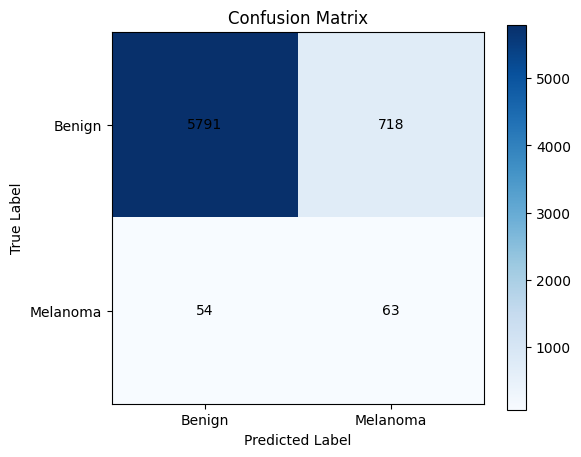

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

# Labels
plt.xticks([0,1], ['Benign', 'Melanoma'])
plt.yticks([0,1], ['Benign', 'Melanoma'])

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Title
plt.title("Confusion Matrix")

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.colorbar()

plt.show()

In [83]:
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        
        images = images.to(device)
        
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        
        all_probs.extend(probs.cpu().numpy())

Improved AUC: 0.8123492389892759


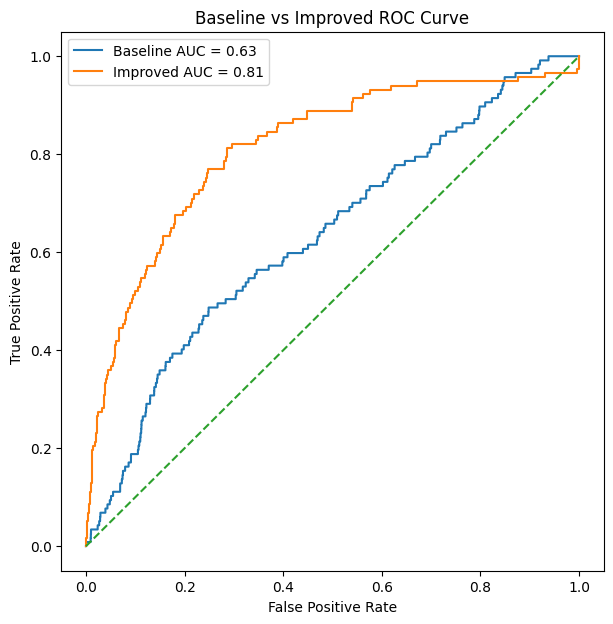

In [85]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert improved model labels/probabilities
all_labels_flat = [int(l) for l in all_labels]
all_probs_flat = [p[0] for p in all_probs]

# Compute improved ROC
improved_fpr, improved_tpr, _ = roc_curve(
    all_labels_flat,
    all_probs_flat
)

improved_auc = auc(improved_fpr, improved_tpr)

print("Improved AUC:", improved_auc)

# Plot ROC curves
plt.figure(figsize=(7,7))

# Baseline ROC
plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Baseline AUC = {baseline_auc:.2f}"
)

# Improved ROC
plt.plot(
    improved_fpr,
    improved_tpr,
    label=f"Improved AUC = {improved_auc:.2f}"
)

# Random classifier
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline vs Improved ROC Curve")

plt.legend()

plt.show()